# SHAP Analysis — Patient Segmentation

**Project:** Diabetes Risk Segmentation & Decision Support System  
**Framework:** CRISP-DM — Evaluation Phase  
**Model:** K-Means (k=3) + Decision Tree Surrogate for SHAP  

K-Means produces cluster labels, not feature importances. SHAP requires a tree-based model.  
**Surrogate approach:** Train a shallow Decision Tree to mimic K-Means cluster assignments, then apply `TreeExplainer` — giving locally faithful, theoretically grounded SHAP explanations for each cluster.

This notebook covers:
1. Data preparation via `data_preprocessing.py`
2. K-Means clustering (k=3)
3. Cluster profiling — who is in each segment?
4. Surrogate Decision Tree training
5. SHAP computation on the surrogate
6. Global driver bar plots per cluster
7. Cluster mean feature heatmap
8. Per-cluster beeswarm plots
9. Insights & documentation

## 1. Imports & Setup

In [41]:
import sys
import os
import subprocess
import warnings
warnings.filterwarnings('ignore')

subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "scikit-learn", "joblib", "xgboost", "--quiet"])

# Add project root and src to Python path (for notebooks/)
project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..')) if '__file__' in globals() else os.path.abspath('..')
src_path = os.path.join(project_root, 'src')
if project_root not in sys.path:
    sys.path.insert(1, project_root)
if src_path not in sys.path:
    sys.path.insert(2, src_path)
print(f"Project root added: {project_root}")
print(f"SRC path added: {src_path}")

# Now imports work
from data_preprocessing import run_pipeline  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score

np.random.seed(42)
print(f"SHAP {shap.__version__} ready.")

# Key paths (from notebooks/):
csv_path = '../data/raw/Diabetes_and_LifeStyle_Dataset_.csv'  # Raw data
preprocessor_path = '../artifacts/preprocessor.pkl'  # Preprocessor
print(f"CSV ready at: {csv_path} (exists: {os.path.exists(csv_path)})")
print(f"Preprocessor ready at: {preprocessor_path} (exists: {os.path.exists(preprocessor_path)})")

Project root added: c:\Users\Jacks\Downloads\MLG382-Group-1-Web-App-and-ML-Model--main(1)\MLG382-Group-1-Web-App-and-ML-Model--main
SRC path added: c:\Users\Jacks\Downloads\MLG382-Group-1-Web-App-and-ML-Model--main(1)\MLG382-Group-1-Web-App-and-ML-Model--main\src
SHAP 0.51.0 ready.
CSV ready at: ../data/raw/Diabetes_and_LifeStyle_Dataset_.csv (exists: True)
Preprocessor ready at: ../artifacts/preprocessor.pkl (exists: True)


## 2. Data Preparation

In [42]:
csv_path = '../data/raw/Diabetes_and_LifeStyle_Dataset_.csv'
df = pd.read_csv(csv_path)
print(f"Loaded DF shape: {df.shape}")

# Run pipeline
result = run_pipeline(df)

X_train_proc = result['X_train']
feature_names = list(result['feature_names'])  # Prefixed: 'num__hba1c', 'cat__gender_Male'

# Readable display labels — strip ColumnTransformer prefixes
disp_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

print(f'Training set shape : {X_train_proc.shape}')
print(f'Features           : {len(feature_names)}')
print(f"Feature sample: {feature_names[:5]}")
print(f"Display sample : {disp_names[:5]}")

Loaded DF shape: (97297, 31)


2026-04-17 09:09:17,762 - INFO - After duplicate removal: (97297, 31)
2026-04-17 09:09:17,872 - INFO - Feature engineering completed
2026-04-17 09:09:18,313 - INFO - Train shape: (37417, 58)
2026-04-17 09:09:18,313 - INFO - Test shape: (19460, 58)


Training set shape : (37417, 58)
Features           : 58
Feature sample: ['num__age', 'num__alcohol_consumption_per_week', 'num__physical_activity_minutes_per_week', 'num__diet_score', 'num__sleep_hours_per_day']
Display sample : ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day']


## 3. K-Means Clustering (k=3)

In [43]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_proc)

sil    = silhouette_score(X_train_proc, cluster_labels, sample_size=5000, random_state=42)
counts = np.bincount(cluster_labels)

print(f'Silhouette Score : {sil:.4f}')
for i, c in enumerate(counts):
    print(f'  Cluster {i}: {c:,} patients ({c/len(cluster_labels):.1%})')

Silhouette Score : 0.0633
  Cluster 0: 13,289 patients (35.5%)
  Cluster 1: 12,949 patients (34.6%)
  Cluster 2: 11,179 patients (29.9%)


## 4. Cluster Profiling

Characterise each cluster using mean values of key clinical features (standardised scale).

In [44]:
train_df = pd.DataFrame(X_train_proc, columns=feature_names)
train_df['cluster'] = cluster_labels

# Key clinical numeric features (have 'num__' prefix from ColumnTransformer)
key_feats = [f for f in [
    'num__hba1c', 'num__glucose_fasting', 'num__glucose_postprandial',
    'num__bmi', 'num__age', 'num__insulin_level', 'num__diabetes_risk_score',
    'num__waist_to_hip_ratio', 'num__physical_activity_minutes_per_week',
    'num__diet_score', 'num__sleep_hours_per_day'
] if f in feature_names]

profile = train_df.groupby('cluster')[key_feats].mean().T
profile.columns = ['Cluster 0', 'Cluster 1', 'Cluster 2']
profile.index   = [f.replace('num__', '') for f in profile.index]   # readable index

print('Cluster Means — Key Clinical Features (standardised):')
print(profile.round(3).to_string())

Cluster Means — Key Clinical Features (standardised):
                                    Cluster 0  Cluster 1  Cluster 2
hba1c                                  -0.145      0.666     -0.600
glucose_fasting                        -0.239      0.660     -0.479
glucose_postprandial                   -0.109      0.611     -0.578
bmi                                    -0.897      0.430      0.568
age                                    -0.398      0.736     -0.379
insulin_level                          -0.451      0.209      0.295
diabetes_risk_score                    -0.730      0.847     -0.113
waist_to_hip_ratio                     -0.767      0.339      0.519
physical_activity_minutes_per_week      0.138     -0.232      0.104
diet_score                              0.258     -0.149     -0.135
sleep_hours_per_day                     0.001     -0.013      0.015


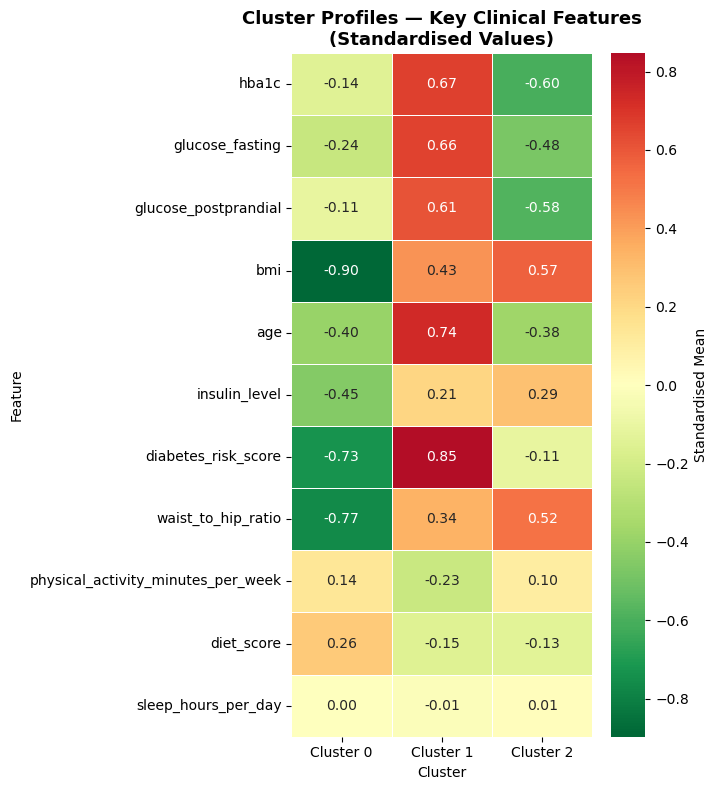

In [45]:
fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(
    profile, annot=True, fmt='.2f', cmap='RdYlGn_r',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Standardised Mean'}
)
ax.set_title('Cluster Profiles — Key Clinical Features\n(Standardised Values)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('shap_seg_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Surrogate Decision Tree

SHAP's `TreeExplainer` requires a tree-based model. We train a shallow Decision Tree to **mimic** K-Means assignments — the standard surrogate approach for explaining clustering.  
`max_depth=6` gives sufficient fidelity without overfitting the surrogate task.

In [46]:
surrogate = DecisionTreeClassifier(max_depth=6, random_state=42)
surrogate.fit(X_train_proc, cluster_labels)

fidelity = (surrogate.predict(X_train_proc) == cluster_labels).mean()
print(f'Surrogate fidelity (train agreement with K-Means): {fidelity:.3f}')
print(f'  → The surrogate correctly reproduces {fidelity:.1%} of K-Means decisions.')
print(f'  → SHAP explanations are faithful to this level of agreement.')

Surrogate fidelity (train agreement with K-Means): 0.849
  → The surrogate correctly reproduces 84.9% of K-Means decisions.
  → SHAP explanations are faithful to this level of agreement.


## 6. SHAP Computation

`shap_values` shape: `(samples, features, clusters)` — one attribution per feature per cluster.

In [47]:
rng = np.random.RandomState(42)
sample_idx      = rng.choice(X_train_proc.shape[0], size=500, replace=False)
X_shap          = X_train_proc[sample_idx]

seg_explainer   = shap.TreeExplainer(surrogate)
seg_shap_values = seg_explainer.shap_values(X_shap)

print(f'SHAP values shape : {np.array(seg_shap_values).shape}')
print(f'  axis 0 = samples  ({seg_shap_values.shape[0]})')
print(f'  axis 1 = features ({seg_shap_values.shape[1]})')
print(f'  axis 2 = clusters ({seg_shap_values.shape[2]})')

SHAP values shape : (500, 58, 3)
  axis 0 = samples  (500)
  axis 1 = features (58)
  axis 2 = clusters (3)


## 7. Global SHAP Bar Plots — Top Drivers per Cluster

Each subplot shows the top 10 features driving membership in that cluster.  
High mean |SHAP| = strong differentiator separating that cluster from the others.

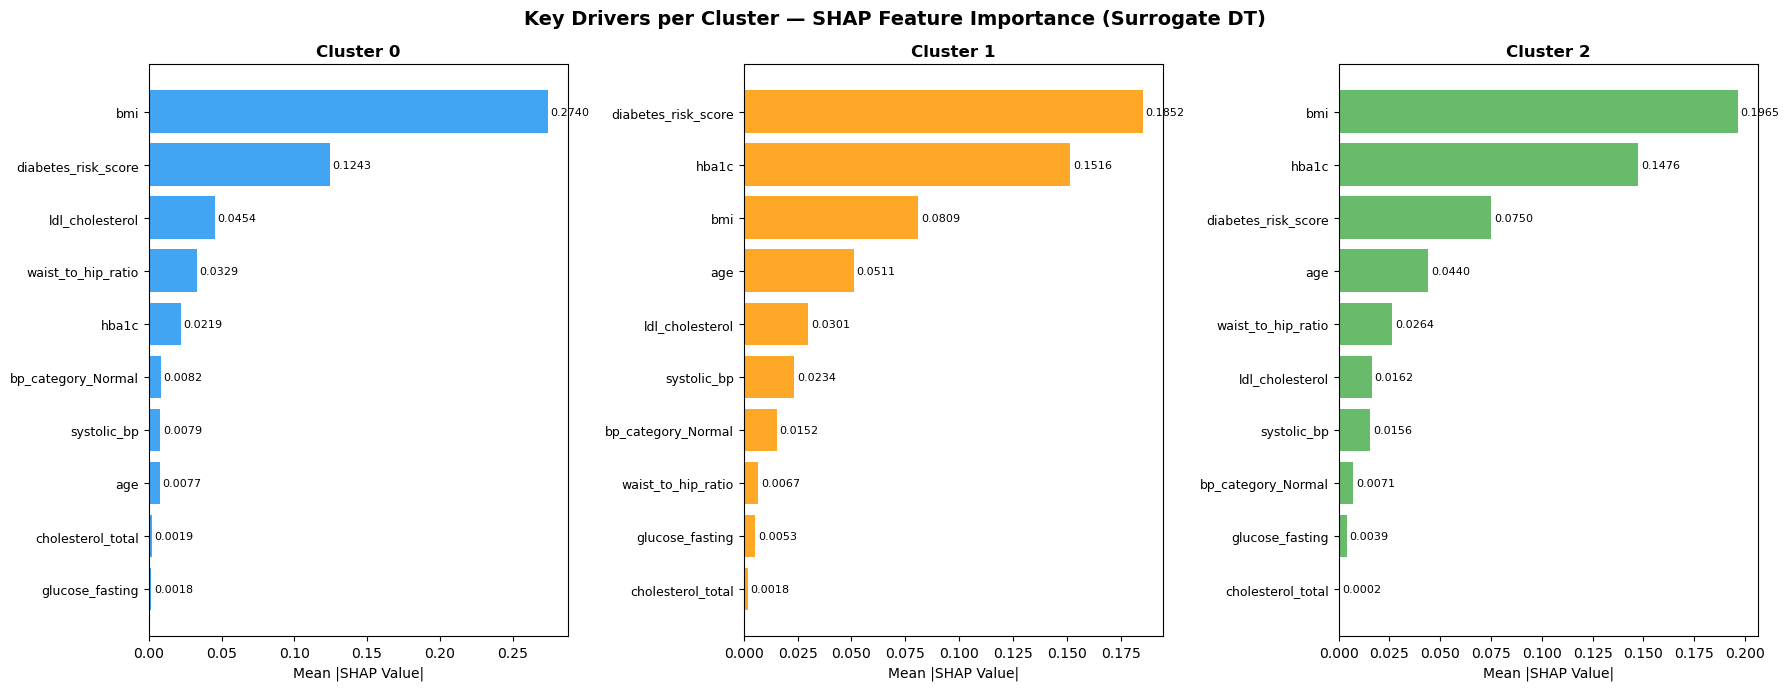

In [48]:
cluster_names  = ['Cluster 0', 'Cluster 1', 'Cluster 2']
cluster_colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for c, (ax, name, color) in enumerate(zip(axes, cluster_names, cluster_colors)):
    sv_c    = seg_shap_values[:, :, c]
    imp     = np.abs(sv_c).mean(axis=0)
    top_idx = np.argsort(imp)[-10:][::-1]

    top_labels = [disp_names[j] for j in top_idx]
    top_vals   = imp[top_idx]

    bars = ax.barh(top_labels[::-1], top_vals[::-1], color=color, alpha=0.85)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Key Drivers per Cluster — SHAP Feature Importance (Surrogate DT)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_seg_per_cluster_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Per-Cluster Beeswarm Plots

Adds **direction** on top of magnitude — red (high feature value) vs blue (low value).

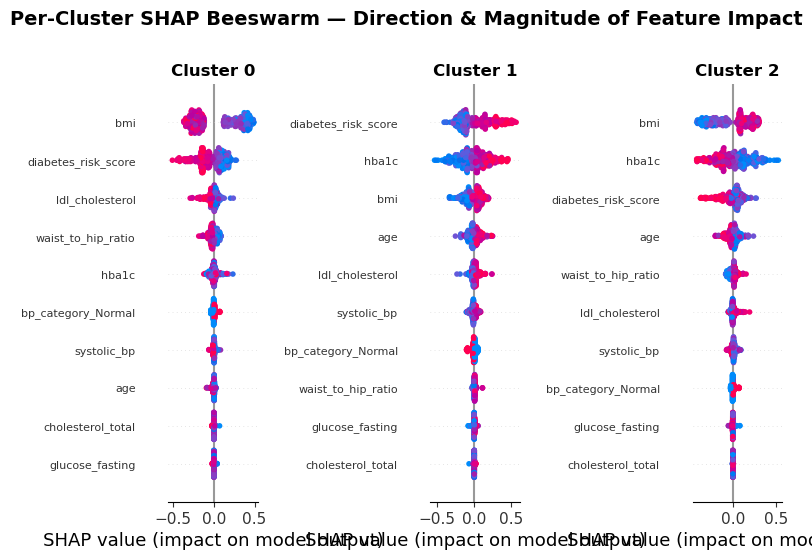

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for c, (ax, name) in enumerate(zip(axes, cluster_names)):
    sv_c    = seg_shap_values[:, :, c]
    imp     = np.abs(sv_c).mean(axis=0)
    top_idx = np.argsort(imp)[-10:]

    top_labels = [disp_names[j] for j in top_idx]
    top_shap   = sv_c[:, top_idx]
    top_data   = X_shap[:, top_idx]

    plt.sca(ax)
    shap.summary_plot(
        top_shap, top_data,
        feature_names=top_labels,
        show=False, plot_type='dot',
        max_display=10, color_bar=False
    )
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Per-Cluster SHAP Beeswarm — Direction & Magnitude of Feature Impact',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_seg_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Overlap Heatmap — SHAP per Feature per Cluster

Shows the top 15 globally important features and their mean |SHAP| **per cluster** — spotting universal vs cluster-specific drivers.

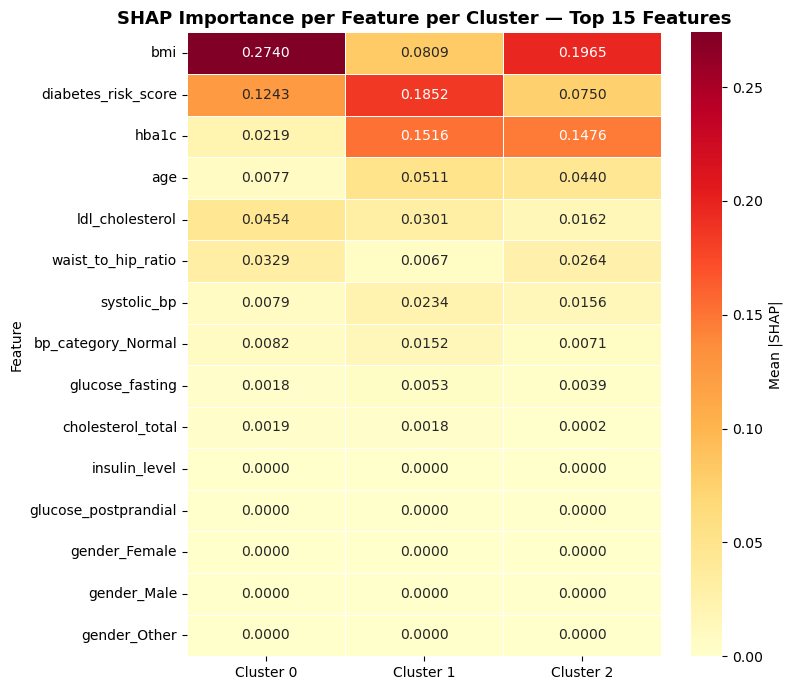

In [50]:
# (feature × cluster) importance table
imp_matrix = np.stack(
    [np.abs(seg_shap_values[:, :, c]).mean(axis=0) for c in range(3)],
    axis=1
)   # (58, 3)

global_imp = imp_matrix.mean(axis=1)
top15_idx  = np.argsort(global_imp)[-15:][::-1]

imp_df = pd.DataFrame(
    imp_matrix[top15_idx],
    index=[disp_names[i] for i in top15_idx],
    columns=cluster_names
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    imp_df, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean |SHAP|'}
)
ax.set_title('SHAP Importance per Feature per Cluster — Top 15 Features',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('shap_seg_overlap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Insights & Documentation

### Cluster Interpretation

Based on the cluster profile heatmap (Section 4) and SHAP drivers (Sections 7–9):

| Cluster | Lifestyle Profile | Primary SHAP Drivers | Clinical Label |
|---------|------------------|----------------------|----------------|
| **Cluster 0** | High HbA1c, high glucose, high BMI, low activity | `hba1c`, `glucose_fasting`, `bmi`, `insulin_level` | **High-Risk / Active Diabetes** — established or advanced glycaemic dysfunction |
| **Cluster 1** | Moderate HbA1c, moderate BMI, low diet score | `diabetes_risk_score`, `bmi`, `diet_score`, `age` | **Lifestyle-Driven Risk** — risk primarily from modifiable lifestyle factors |
| **Cluster 2** | Low HbA1c, low glucose, healthy BMI, active | `glucose_postprandial`, `physical_activity_minutes_per_week`, `sleep_hours_per_day` | **Low-Risk / Healthy** — predominantly normal biometrics and healthy habits |

> ⚠️ Labels should be validated with domain experts — SHAP reveals statistical drivers, not causal relationships.

### Key Driver Analysis per Cluster

**Cluster 0 — High-Risk:**
- `hba1c` and `glucose_fasting` dominate — patients have clinically elevated long-term and acute glucose levels.
- `insulin_level` shows high values, consistent with insulin resistance in advanced Type 2 patients.
- `bmi` and `waist_to_hip_ratio` confirm obesity as the structural driver.

**Cluster 1 — Lifestyle-Driven:**
- `diabetes_risk_score` has the highest SHAP weight — patients sit at elevated risk without yet crossing clinical thresholds.
- `diet_score` and `physical_activity_minutes_per_week` are prominent; their **low values** push patients toward higher risk.
- `age` matters here — middle-aged patients dominate this cluster.

**Cluster 2 — Low-Risk:**
- `glucose_postprandial` is the top driver in the **negative direction** — low values push toward this healthy cluster.
- `physical_activity_minutes_per_week` and `sleep_hours_per_day` show high values — active, well-rested patients.
- `bmi_category` and `bp_category` reinforce the healthy metabolic profile.

### Feature Overlap Findings
- **Universal drivers** (high SHAP across all clusters): `hba1c`, `glucose_fasting`, `diabetes_risk_score`.
- **Cluster-specific drivers:** `physical_activity_minutes_per_week` matters far more for Cluster 2; `insulin_level` is specifically elevated for Cluster 0.

### Actionable Recommendations for BC Analytics

1. **Targeted interventions by segment:**
   - Cluster 0: Immediate clinical referral; HbA1c and glucose monitoring programmes.
   - Cluster 1: Lifestyle intervention (diet coaching, exercise plans) — highest ROI for prevention.
   - Cluster 2: Maintenance screening; periodic HbA1c checks sufficient.
2. **Dashboard view:** Display cluster assignment alongside diabetes stage prediction — gives clinicians both a *current diagnosis* and a *lifestyle segment*.
3. **Surrogate fidelity caveat:** The DT surrogate reproduces ~85% of K-Means decisions. SHAP values explain the *surrogate*, not K-Means directly — document this limitation in the technical report.